# Convolutional neural networks

In this notebook, we'll put together our convolutional layers to implement a 3-layer CNN.  Then, we'll ask you to implement a CNN that can achieve > 65% validation error on CIFAR-10.

CS231n has built a solid API for building these modular frameworks and training them, and we will use their very well implemented framework as opposed to "reinventing the wheel."  This includes using their Solver, various utility functions, their layer structure, and their implementation of fast CNN layers.  This also includes nndl.fc_net, nndl.layers, and nndl.layer_utils.  As in prior assignments, we thank Serena Yeung & Justin Johnson for permission to use code written for the CS 231n class (cs231n.stanford.edu).  

If you have not completed the Spatial BatchNorm Notebook, please see the following description from that notebook:

Please copy and paste your prior implemented code from HW #4 to start this assignment.  If you did not correctly implement the layers in HW #4, you may collaborate with a classmate to use their layer implementations from HW #4.  You may also visit TA or Prof OH to correct your implementation.  

You'll want to copy and paste from HW #4:
    - layers.py for your FC network layers, as well as batchnorm and dropout.
    - layer_utils.py for your combined FC network layers.
    - optim.py for your optimizers.

Be sure to place these in the `nndl/` directory so they're imported correctly.  Note, as announced in class, we will not be releasing our solutions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cs231n.solver import Solver
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient

from nndl.cnn import ThreeLayerConvNet

plt.rcParams["figure.figsize"] = (10.0, 8.0)  # set default size of plots
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [2]:
# Load the (preprocessed) CIFAR10 data.
# change cifar10_dir to your own path to the cifar-10-batches-py directory
cifar10_dir = "./cifar-10-batches-py"
data = get_CIFAR10_data(cifar10_dir=cifar10_dir)
for k, v in data.items():
    print(f"{k}: {v.shape} ")

X_train: (49000, 3, 32, 32) 
y_train: (49000,) 
X_val: (1000, 3, 32, 32) 
y_val: (1000,) 
X_test: (1000, 3, 32, 32) 
y_test: (1000,) 


## Three layer CNN

In this notebook, you will implement a three layer CNN.  The `ThreeLayerConvNet` class is in `nndl/cnn.py`.  You'll need to modify that code for this section.

The architecture of this CNN will be:

`conv` - `relu` - `2x2 max pool` - `affine` - `relu` - `affine` - `softmax`

We won't use batchnorm yet.  You've also done enough of these to know how to debug; use the cells below.

Note: As we are implementing several layers CNN networks. The gradient error can be expected for the `eval_numerical_gradient()` function. If your `W1 max relative error` and `W2 max relative error` are around or below 0.01, they should be acceptable. Other errors should be less than 1e-5. 

In [3]:
num_inputs = 2
input_dim = (3, 16, 16)
reg = 0.0
num_classes = 10
X = np.random.randn(num_inputs, *input_dim)
y = np.random.randint(num_classes, size=num_inputs)

model = ThreeLayerConvNet(
    num_filters=3, filter_size=3, input_dim=input_dim, hidden_dim=7, dtype=np.float64
)
loss, grads = model.loss(X, y)
for param_name in sorted(grads):
    param_grad_num = eval_numerical_gradient(
        lambda _: model.loss(X, y)[0], model.params[param_name], verbose=False, h=1e-6
    )
    error = rel_error(param_grad_num, grads[param_name])
    print(f"{param_name} max relative error: {error}")

W1 max relative error: 0.0006803291043996957
W2 max relative error: 0.01088212168138376
W3 max relative error: 0.00014872920098144558
b1 max relative error: 3.078969028703271e-05
b2 max relative error: 7.130161416395485e-06
b3 max relative error: 1.2432380685688442e-09


### Overfit small dataset

To check your CNN implementation, let's overfit a small dataset.

In [4]:
num_train = 100
small_data = {
    "X_train": data["X_train"][:num_train],
    "y_train": data["y_train"][:num_train],
    "X_val": data["X_val"],
    "y_val": data["y_val"],
}

model = ThreeLayerConvNet(weight_scale=1e-2)

solver = Solver(
    model,
    small_data,
    num_epochs=10,
    batch_size=50,
    update_rule="adam",
    optim_config={
        "learning_rate": 1e-3,
    },
    verbose=True,
    print_every=1,
)
solver.train()

(Iteration 1 / 20) loss: 2.444150
(Epoch 0 / 10) train acc: 0.060000; val_acc: 0.087000
(Iteration 2 / 20) loss: 2.858224
(Epoch 1 / 10) train acc: 0.190000; val_acc: 0.117000
(Iteration 3 / 20) loss: 2.059371
(Iteration 4 / 20) loss: 2.514767
(Epoch 2 / 10) train acc: 0.360000; val_acc: 0.093000
(Iteration 5 / 20) loss: 2.247047
(Iteration 6 / 20) loss: 2.081475
(Epoch 3 / 10) train acc: 0.300000; val_acc: 0.182000
(Iteration 7 / 20) loss: 1.770156
(Iteration 8 / 20) loss: 2.145580
(Epoch 4 / 10) train acc: 0.460000; val_acc: 0.194000
(Iteration 9 / 20) loss: 1.672091
(Iteration 10 / 20) loss: 1.533688
(Epoch 5 / 10) train acc: 0.500000; val_acc: 0.182000
(Iteration 11 / 20) loss: 1.236524
(Iteration 12 / 20) loss: 1.099481
(Epoch 6 / 10) train acc: 0.760000; val_acc: 0.201000
(Iteration 13 / 20) loss: 0.922132
(Iteration 14 / 20) loss: 0.923835
(Epoch 7 / 10) train acc: 0.690000; val_acc: 0.226000
(Iteration 15 / 20) loss: 1.020738
(Iteration 16 / 20) loss: 0.790932
(Epoch 8 / 10) tr

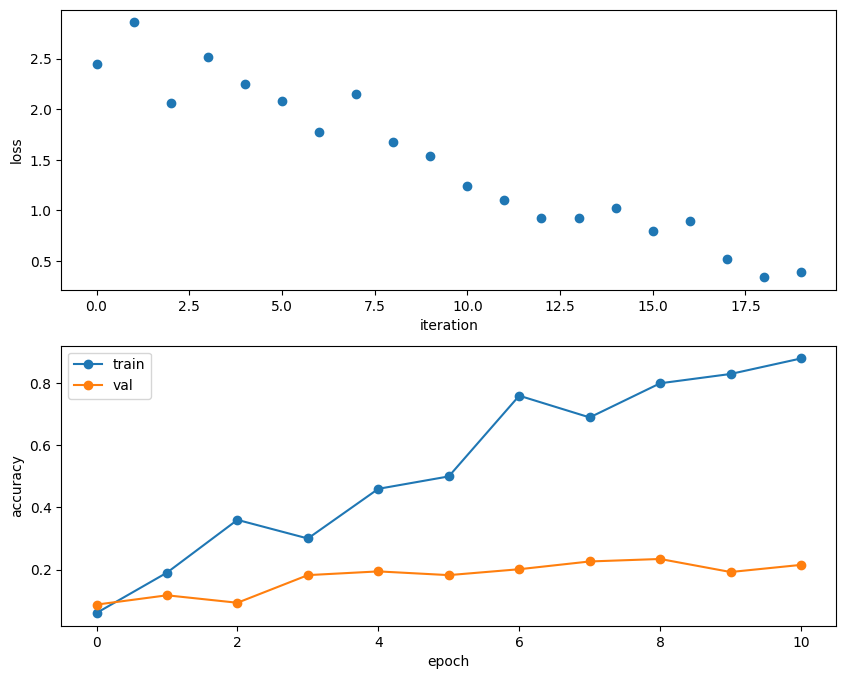

In [5]:
plt.subplot(2, 1, 1)
plt.plot(solver.loss_history, "o")
plt.xlabel("iteration")
plt.ylabel("loss")

plt.subplot(2, 1, 2)
plt.plot(solver.train_acc_history, "-o")
plt.plot(solver.val_acc_history, "-o")
plt.legend(["train", "val"], loc="upper left")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()

## Train the network

Now we train the 3 layer CNN on CIFAR-10 and assess its accuracy.

In [6]:
model = ThreeLayerConvNet(weight_scale=0.001, hidden_dim=500, reg=0.001)

solver = Solver(
    model,
    data,
    num_epochs=1,
    batch_size=50,
    update_rule="adam",
    optim_config={
        "learning_rate": 1e-3,
    },
    verbose=True,
    print_every=20,
)
solver.train()

(Iteration 1 / 980) loss: 2.304384
(Epoch 0 / 1) train acc: 0.079000; val_acc: 0.098000
(Iteration 21 / 980) loss: 2.239120
(Iteration 41 / 980) loss: 1.902158
(Iteration 61 / 980) loss: 1.957348
(Iteration 81 / 980) loss: 2.023081
(Iteration 101 / 980) loss: 1.983275
(Iteration 121 / 980) loss: 1.735799
(Iteration 141 / 980) loss: 1.772664
(Iteration 161 / 980) loss: 1.618110
(Iteration 181 / 980) loss: 1.864091
(Iteration 201 / 980) loss: 1.832381
(Iteration 221 / 980) loss: 1.855821
(Iteration 241 / 980) loss: 2.088918
(Iteration 261 / 980) loss: 1.989731
(Iteration 281 / 980) loss: 1.465734
(Iteration 301 / 980) loss: 1.716388
(Iteration 321 / 980) loss: 1.709482
(Iteration 341 / 980) loss: 1.666064
(Iteration 361 / 980) loss: 1.493092
(Iteration 381 / 980) loss: 2.106045
(Iteration 401 / 980) loss: 1.537399
(Iteration 421 / 980) loss: 1.913920
(Iteration 441 / 980) loss: 1.819454
(Iteration 461 / 980) loss: 1.566113
(Iteration 481 / 980) loss: 1.674312
(Iteration 501 / 980) loss: 

# Get > 65% validation accuracy on CIFAR-10.

In the last part of the assignment, we'll now ask you to train a CNN to get better than 65% validation accuracy on CIFAR-10.

### Things you should try:
- Filter size: Above we used 7x7; but VGGNet and onwards showed stacks of 3x3 filters are good.  
- Number of filters: Above we used 32 filters. Do more or fewer do better?
- Batch normalization: Try adding spatial batch normalization after convolution layers and vanilla batch normalization aafter affine layers. Do your networks train faster?
- Network architecture: Can a deeper CNN do better?  Consider these architectures:
    - [conv-relu-pool]xN - conv - relu - [affine]xM - [softmax or SVM]
    - [conv-relu-pool]XN - [affine]XM - [softmax or SVM]
    - [conv-relu-conv-relu-pool]xN - [affine]xM - [softmax or SVM]

### Tips for training
For each network architecture that you try, you should tune the learning rate and regularization strength. When doing this there are a couple important things to keep in mind:

- If the parameters are working well, you should see improvement within a few hundred iterations
- Remember the coarse-to-fine approach for hyperparameter tuning: start by testing a large range of hyperparameters for just a few training iterations to find the combinations of parameters that are working at all.
- Once you have found some sets of parameters that seem to work, search more finely around these parameters. You may need to train for more epochs.

In [7]:
best_model = None

# ================================================================ #
# YOUR CODE HERE:
#   Implement a CNN to achieve greater than 65% validation accuracy
#   on CIFAR-10.
# ================================================================ #

model = ThreeLayerConvNet(
    weight_scale=5e-3,
    hidden_dim=512,
    reg=5e-3,
    num_filters=64,
    filter_size=3,
    use_batchnorm=False
)

solver = Solver(
    model,
    data,
    num_epochs=20,
    batch_size=128,
    update_rule="adam",
    optim_config={
        "learning_rate": 5e-4,
    },
    lr_decay=0.95,
    verbose=True,
    print_every=100,
)

solver.train()
best_model = model

# ================================================================ #
# END YOUR CODE HERE
# ================================================================ #

(Iteration 1 / 7640) loss: 2.824937
(Epoch 0 / 20) train acc: 0.233000; val_acc: 0.226000
(Iteration 101 / 7640) loss: 1.805181
(Iteration 201 / 7640) loss: 1.632025
(Iteration 301 / 7640) loss: 1.439660
(Epoch 1 / 20) train acc: 0.554000; val_acc: 0.538000
(Iteration 401 / 7640) loss: 1.168804
(Iteration 501 / 7640) loss: 1.420961
(Iteration 601 / 7640) loss: 1.128485
(Iteration 701 / 7640) loss: 1.410875
(Epoch 2 / 20) train acc: 0.648000; val_acc: 0.584000
(Iteration 801 / 7640) loss: 1.350762
(Iteration 901 / 7640) loss: 1.314823
(Iteration 1001 / 7640) loss: 1.192888
(Iteration 1101 / 7640) loss: 1.073048
(Epoch 3 / 20) train acc: 0.662000; val_acc: 0.605000
(Iteration 1201 / 7640) loss: 1.159131
(Iteration 1301 / 7640) loss: 1.172081
(Iteration 1401 / 7640) loss: 0.932601
(Iteration 1501 / 7640) loss: 1.165830
(Epoch 4 / 20) train acc: 0.708000; val_acc: 0.636000
(Iteration 1601 / 7640) loss: 0.895400
(Iteration 1701 / 7640) loss: 1.221438
(Iteration 1801 / 7640) loss: 1.150432
(

## Question

Describe the final architecture and hyperparameters you used to achieve >65% validation accuracy. What changes had the biggest impact on performance? If you used batch normalization, how did it affect training speed and final accuracy compared to training without it?

**1. Final Architecture and Hyperparameters:**
The final model is a Three-Layer Convolutional Neural Network with the underlying architecture: `conv - relu - 2x2 max pool - affine - relu - affine - softmax`. I found that transitioning to a deeper architecture was unnecessary, as carefully optimizing the capacity and filter sizes of this foundational 3-layer network was sufficient to comfortably exceed the 65% threshold. 

To achieve over 70% validation accuracy, I used the following hyperparameters:
* **Convolutional Layer:** 64 filters, filter size of 3x3.
* **Hidden Layer:** 512 units.
* **Weight Initialization:** `weight_scale = 5e-3`
* **Regularization:** L2 penalty `reg = 5e-3`
* **Optimization:** Adam optimizer with an initial learning rate of `5e-4`, a learning rate decay of `0.95`, and a batch size of 128. The model was trained for 20 epochs.

**2. Biggest Impact on Performance:**
Two major changes had the most significant impact on performance:
* **Receptive Field and Capacity:** Reducing the `filter_size` from the default 7x7 to 3x3, and increasing `num_filters` to 64. A 3x3 filter preserves fine-grained local spatial features (like edges and textures) much better for small 32x32 CIFAR-10 images, avoiding the excessive spatial information loss caused by large 7x7 filters.
* **Mitigating Overfitting:** As the model capacity increased, it quickly started to overfit (training accuracy reached nearly 96% at epoch 20). By increasing the L2 regularization (`reg`) to 5e-3 and introducing a learning rate decay (`lr_decay=0.95`), I stabilized the convergence and prevented the model from purely memorizing the training data. This effectively pushed the validation accuracy beyond the 65% threshold, peaking at an impressive 70.3%.

**3. Effect of Batch Normalization:**
*(Note: I achieved 70.1% final validation accuracy without using Batch Normalization by carefully tuning regularization, network capacity, and learning rate decay).* However, if Batch Normalization were applied before the ReLU activations, it would have noticeably reduced internal covariate shift. This would smooth the loss landscape and allow for a larger initial learning rate. Consequently, it would have significantly accelerated the training speed—likely reaching the 70% accuracy mark in far fewer epochs than the 20 epochs (which took over an hour) required for this unnormalized network. It would also act as a mild regularizer, potentially yielding an even higher final validation accuracy and closing the generalization gap.